# Ứng dụng 2: Dự đoán Giá Nhà (House Price Prediction)
## Assignment 02 — Phát triển Hệ thống Thông minh (Intelligent System Development)

**Bài toán**: Hồi quy (Regression) — Dự đoán giá trị bất động sản thực tế tại Mỹ dựa trên các đặc trưng vật lý và vị trí địa lý.

**Quy trình phát triển chuẩn công nghiệp**:
$$
\text{Dữ liệu thô (Raw Data)} \rightarrow \text{Hiểu (Understand)} \rightarrow \text{Làm sạch (Clean)} \rightarrow \text{Biểu diễn (Represent)} \rightarrow \text{Học (Learn)} \rightarrow \text{Đánh giá (Evaluate)} \rightarrow \text{Lưu trữ (Persist)} \rightarrow \text{Triển khai (Deploy)}
$$

**Dataset**: `realtor-data.zip.csv` (Tập dữ liệu 2.2 triệu bất động sản từ Kaggle — lấy mẫu đại diện ~100,000 dòng để tối ưu tính toán)

In [1]:
# 0.1 Khai báo các thư viện cần thiết
import time
import pickle
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Tiền xử lý, Mô hình, Tuning & Đánh giá
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)

print("Import toàn bộ thư viện thành công!")

Import toàn bộ thư viện thành công!


In [2]:
# 0.2 Cấu hình giao diện biểu đồ và Pandas hiển thị
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print("Đã thiết lập cấu hình hiển thị biểu đồ và bảng dữ liệu.")

Đã thiết lập cấu hình hiển thị biểu đồ và bảng dữ liệu.


---
## Phần 1: Hiểu và Làm sạch Dữ liệu (Data Understanding & Cleaning)

**Mục tiêu**: Khảo sát dữ liệu thô (2.2 triệu dòng), phát hiện và giải quyết các vấn đề về chất lượng dữ liệu (missing values, ngoại lai phi thực tế), sau đó lấy mẫu đại diện 100,000 dòng để huấn luyện.

In [3]:
# 1.1 Đọc dữ liệu thô
df_raw = pd.read_csv('../../DATA/realtor-data.zip.csv')
print(f"Đọc dữ liệu thành công! Kích thước thô: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")

Đọc dữ liệu thành công! Kích thước thô: 2,226,382 dòng × 12 cột


In [4]:
# 1.2 Kiểm tra kiểu dữ liệu các cột
df_raw.dtypes

brokered_by       float64
status                str
price             float64
bed               float64
bath              float64
acre_lot          float64
street            float64
city                  str
state                 str
zip_code          float64
house_size        float64
prev_sold_date        str
dtype: object

In [5]:
# 1.3 Hiển thị 5 dòng đầu tiên
df_raw.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,"103,378.00",for_sale,"105,000.00",3.00,2.00,0.12,"1,962,661.00",Adjuntas,Puerto Rico,601.00,920.00,NaN
1,"52,707.00",for_sale,"80,000.00",4.00,2.00,0.08,"1,902,874.00",Adjuntas,Puerto Rico,601.00,"1,527.00",NaN
2,"103,379.00",for_sale,"67,000.00",2.00,1.00,0.15,"1,404,990.00",Juana Diaz,Puerto Rico,795.00,748.00,NaN
3,"31,239.00",for_sale,"145,000.00",4.00,2.00,0.10,"1,947,675.00",Ponce,Puerto Rico,731.00,"1,800.00",NaN
4,"34,632.00",for_sale,"65,000.00",6.00,2.00,0.05,"331,151.00",Mayaguez,Puerto Rico,680.00,NaN,NaN


In [6]:
# 1.4 Thống kê mô tả số học (Descriptive Statistics)
df_raw.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,"2,221,849.00","2,224,841.00","1,745,065.00","1,714,611.00","1,900,793.00","2,215,516.00","2,226,083.00","1,657,898.00"
mean,"52,939.89","524,195.52",3.28,2.50,15.22,"1,012,324.92","52,186.68","2,714.47"
std,"30,642.75","2,138,893.22",1.57,1.65,762.82,"583,763.48","28,954.08","808,163.52"
min,0.00,0.00,1.00,1.00,0.00,0.00,0.00,4.00
25%,"23,861.00","165,000.00",3.00,2.00,0.15,"506,312.75","29,617.00","1,300.00"
50%,"52,884.00","325,000.00",3.00,2.00,0.26,"1,012,765.50","48,382.00","1,760.00"
75%,"79,183.00","550,000.00",4.00,3.00,0.98,"1,521,173.25","78,070.00","2,413.00"
max,"110,142.00","2,147,483,600.00",473.00,830.00,"100,000.00","2,001,357.00","99,999.00","1,040,400,400.00"


In [7]:
# 1.5 Kiểm tra số lượng giá trị bị thiếu (Missing Values)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ (%)': missing_pct}).sort_values('Tỷ lệ (%)', ascending=False)

,Số lượng thiếu,Tỷ lệ (%)
prev_sold_date,734297,32.98
house_size,568484,25.53
bath,511771,22.99
bed,481317,21.62
acre_lot,325589,14.62
street,10866,0.49
brokered_by,4533,0.20
price,1541,0.07
city,1407,0.06
zip_code,299,0.01


In [8]:
# 1.6 Khảo sát biến mục tiêu giá nhà (Price)
print(f"Giá nhà: Min = ${df_raw['price'].min():,.0f} | Max = ${df_raw['price'].max():,.0f}")
print(f"Số dòng có giá = $0 (bất thường): {(df_raw['price'] == 0).sum():,} dòng")
print(f"Số dòng có giá > $10,000,000:     {(df_raw['price'] > 10_000_000).sum():,} dòng")

Giá nhà: Min = $0 | Max = $2,147,483,600
Số dòng có giá = $0 (bất thường): 280 dòng
Số dòng có giá > $10,000,000:     3,996 dòng


### Nhận xét & Kế hoạch làm sạch:
1. **Giá trị bị thiếu (Missing Values)**: `prev_sold_date` (33%), `house_size` (25.5%), `bath` (23%), `bed` (21.6%), `acre_lot` (14.6%) $\rightarrow$ Cần xử lý loại bỏ hoặc điền giá trị phù hợp.
2. **Cột không liên quan**: `brokered_by` (ID nhà môi giới), `street` (địa chỉ chi tiết quá nhiều giá trị duy nhất), `prev_sold_date` (thời gian quá khứ), `zip_code` (đã có state và city) $\rightarrow$ Loại bỏ.
3. **Ngoại lai cực đoan (Extreme Outliers)**: Giá > $2 tỷ (lỗi nhập liệu), số phòng ngủ > 100, diện tích > 1 triệu sqft $\rightarrow$ Lọc và giới hạn miền giá trị thực tế.
4. **Lấy mẫu (Sampling)**: Lấy mẫu ngẫu nhiên 100,000 dòng đại diện để đảm bảo tốc độ huấn luyện tối ưu trên môi trường máy tính cá nhân.

---
### Thực hiện làm sạch dữ liệu

In [9]:
# 1.7 Loại bỏ các cột không liên quan trực tiếp đến bài toán định giá
cols_to_drop = ['brokered_by', 'street', 'prev_sold_date', 'zip_code']
df = df_raw.drop(columns=cols_to_drop)
print(f"Đã loại bỏ {len(cols_to_drop)} cột: {cols_to_drop}")
print(f"Các cột còn lại ({len(df.columns)}): {list(df.columns)}")

Đã loại bỏ 4 cột: ['brokered_by', 'street', 'prev_sold_date', 'zip_code']
Các cột còn lại (8): ['status', 'price', 'bed', 'bath', 'acre_lot', 'city', 'state', 'house_size']


*Lý do (WHY)*:
- **`brokered_by`**: Mã số đại lý môi giới — không phản ánh giá trị nội tại của bất động sản.
- **`street`**: Địa chỉ cụ thể có độ phân mảnh cực cao (~1.7 triệu giá trị duy nhất) $\rightarrow$ không thể mã hóa hiệu quả.
- **`prev_sold_date`**: Bị thiếu 33% và không quyết định giá thị trường hiện tại.
- **`zip_code`**: Đã có thông tin địa lý cấp bang (`state`) và thành phố (`city`).

In [10]:
# 1.8 Loại bỏ các dòng có giá bằng 0 hoặc bị thiếu (không hợp lệ)
n_before = len(df)
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]
print(f"Đã loại bỏ {n_before - len(df):,} dòng có giá không hợp lệ.")
print(f"Kích thước hiện tại: {len(df):,} dòng")

Đã loại bỏ 1,821 dòng có giá không hợp lệ.
Kích thước hiện tại: 2,224,561 dòng


In [11]:
# 1.9 Loại bỏ dòng bị thiếu ở các đặc trưng vật lý cốt lõi
# Các đặc trưng cốt lõi bắt buộc: bed, bath, house_size, city, state
n_before = len(df)
df = df.dropna(subset=['bed', 'bath', 'house_size', 'city', 'state'])
print(f"Đã loại bỏ {n_before - len(df):,} dòng bị thiếu thông tin cốt lõi.")
print(f"Kích thước hiện tại: {len(df):,} dòng")

Đã loại bỏ 619,425 dòng bị thiếu thông tin cốt lõi.
Kích thước hiện tại: 1,605,136 dòng


*Lý do (WHY)*: Số phòng ngủ (`bed`), số phòng tắm (`bath`) và diện tích (`house_size`) là 3 trụ cột định giá nhà. Việc tự ý điền giá trị trung bình cho các cột này sẽ tạo ra dữ liệu giả mạo làm sai lệch mô hình.

In [12]:
# 1.10 Điền giá trị bị thiếu cho acre_lot bằng trung vị (Median)
median_acre = df['acre_lot'].median()
df['acre_lot'] = df['acre_lot'].fillna(median_acre)
print(f"Đã điền các giá trị thiếu của acre_lot bằng trung vị: {median_acre:.3f} acre")

Đã điền các giá trị thiếu của acre_lot bằng trung vị: 0.210 acre


In [13]:
# 1.11 Lọc bỏ các giá trị ngoại lai cực đoan (Outlier Filtering)
print("=== LỌC NGOẠI LAI CỰC ĐOAN ===")

# Giữ nhà ở dân dụng có giá từ $10,000 đến $5,000,000
n0 = len(df)
df = df[(df['price'] >= 10_000) & (df['price'] <= 5_000_000)]
print(f"Khoảng giá [$10K, $5M]:      Đã lọc {n0 - len(df):,} dòng")

# Số phòng ngủ tối đa 10
n0 = len(df)
df = df[df['bed'] <= 10]
print(f"Số phòng ngủ <= 10:          Đã lọc {n0 - len(df):,} dòng")

# Số phòng tắm tối đa 10
n0 = len(df)
df = df[df['bath'] <= 10]
print(f"Số phòng tắm <= 10:          Đã lọc {n0 - len(df):,} dòng")

# Diện tích nhà từ 100 đến 10,000 sqft
n0 = len(df)
df = df[(df['house_size'] >= 100) & (df['house_size'] <= 10_000)]
print(f"Diện tích [100, 10000] sqft: Đã lọc {n0 - len(df):,} dòng")

# Diện tích đất tối đa 10 acre
n0 = len(df)
df = df[df['acre_lot'] <= 10]
print(f"Diện tích đất <= 10 acre:    Đã lọc {n0 - len(df):,} dòng")

print(f"\nTổng số dòng hợp lệ sau lọc ngoại lai: {len(df):,} dòng")

=== LỌC NGOẠI LAI CỰC ĐOAN ===
Khoảng giá [$10K, $5M]:      Đã lọc 10,848 dòng
Số phòng ngủ <= 10:          Đã lọc 2,395 dòng
Số phòng tắm <= 10:          Đã lọc 333 dòng
Diện tích [100, 10000] sqft: Đã lọc 1,472 dòng
Diện tích đất <= 10 acre:    Đã lọc 33,100 dòng

Tổng số dòng hợp lệ sau lọc ngoại lai: 1,556,988 dòng


*Lý do (WHY)*: Các mẫu có diện tích hàng trăm ngàn sqft hoặc giá hàng trăm triệu USD là các tổ hợp thương mại, nông trại lớn hoặc lỗi nhập liệu. Giữ chúng sẽ làm bóp méo hàm mất mát sai số bình phương (MSE) của các thuật toán hồi quy.

In [14]:
# 1.12 Lấy mẫu ngẫu nhiên đại diện 100,000 dòng
SAMPLE_SIZE = 100_000

if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"Đã lấy mẫu ngẫu nhiên {SAMPLE_SIZE:,} dòng đại diện (random_state=42).")
else:
    print(f"Dữ liệu có {len(df):,} dòng — giữ nguyên toàn bộ.")

df = df.reset_index(drop=True)
print(f"Kích thước tập làm việc chính thức: {df.shape[0]:,} dòng × {df.shape[1]} cột")

Đã lấy mẫu ngẫu nhiên 100,000 dòng đại diện (random_state=42).
Kích thước tập làm việc chính thức: 100,000 dòng × 8 cột


In [15]:
# 1.13 Mã hóa biến phân loại: status (Label Encoding)
print("Phân phối của cột 'status':")
print(df['status'].value_counts())

status_map = {'for_sale': 0, 'ready_to_build': 1, 'sold': 2}
df['status'] = df['status'].map(status_map)
print("\nĐã mã hóa cột status: for_sale -> 0, ready_to_build -> 1, sold -> 2")

Phân phối của cột 'status':
status
for_sale    55948
sold        44052
Name: count, dtype: int64

Đã mã hóa cột status: for_sale -> 0, ready_to_build -> 1, sold -> 2


In [16]:
# 1.14 Mã hóa biến 'state' bằng LabelEncoder
le_state = LabelEncoder()
df['state_encoded'] = le_state.fit_transform(df['state'])
state_classes = list(le_state.classes_)
print(f"Đã mã hóa {len(state_classes)} bang thành các số nguyên [0, {df['state_encoded'].max()}]")
print(f"Ví dụ: {state_classes[:5]} -> {list(le_state.transform(state_classes[:5]))}")

Đã mã hóa 54 bang thành các số nguyên [0, 53]
Ví dụ: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California'] -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [17]:
# 1.15 Mã hóa biến 'city' bằng Frequency Encoding (Tần suất xuất hiện)
# Do số lượng thành phố rất lớn (~10,000), Frequency Encoding tránh làm bùng nổ số chiều
city_freq = df['city'].value_counts(normalize=True)
df['city_freq'] = df['city'].map(city_freq)
print(f"Đã mã hóa {df['city'].nunique():,} thành phố bằng Frequency Encoding.")

Đã mã hóa 9,204 thành phố bằng Frequency Encoding.


In [18]:
# 1.16 Loại bỏ các cột gốc 'city' và 'state' đã được mã hóa
df = df.drop(columns=['city', 'state'])
print(f"Danh sách các cột đặc trưng số hóa ({len(df.columns)} cột):")
list(df.columns)

Danh sách các cột đặc trưng số hóa (8 cột):


['status',
 'price',
 'bed',
 'bath',
 'acre_lot',
 'house_size',
 'state_encoded',
 'city_freq']

In [19]:
# 1.17 Kiểm tra cấu trúc DataFrame sau khi hoàn tất làm sạch
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   status         100000 non-null  int64  
 1   price          100000 non-null  float64
 2   bed            100000 non-null  float64
 3   bath           100000 non-null  float64
 4   acre_lot       100000 non-null  float64
 5   house_size     100000 non-null  float64
 6   state_encoded  100000 non-null  int64  
 7   city_freq      100000 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 6.1 MB


In [20]:
# 1.18 Xem 5 dòng dữ liệu sạch đầu tiên
df.head()

,status,price,bed,bath,acre_lot,house_size,state_encoded,city_freq
0,2,"420,000.00",4.00,3.00,0.16,"3,112.00",45,0.00
1,2,"264,000.00",2.00,2.00,0.06,"1,280.00",21,0.00
2,0,"399,000.00",3.00,2.00,0.44,"1,656.00",4,0.00
3,2,"459,900.00",4.00,3.00,0.18,"3,098.00",10,0.00
4,0,"299,900.00",3.00,2.00,0.17,"1,081.00",2,0.01


---
## Phần 2: Biểu diễn Dữ liệu (Data Representation)

**Mục tiêu**: Định hình ma trận đặc trưng $X \in \mathbb{R}^{N \times d}$ và vector mục tiêu giá nhà $y \in \mathbb{R}^{N}$.

In [21]:
# 2.1 Tách ma trận đặc trưng X và vector mục tiêu y (price)
X = df.drop(columns=['price'])
y = df['price']

N, d = X.shape
print(f"Ma trận đặc trưng (Feature Matrix): X ∈ R^({N:,} × {d})")
print(f"Vector mục tiêu (Target Vector):    y ∈ R^({len(y):,})")

Ma trận đặc trưng (Feature Matrix): X ∈ R^(100,000 × 7)
Vector mục tiêu (Target Vector):    y ∈ R^(100,000)


In [22]:
# 2.2 Xem 5 dòng đầu của ma trận đặc trưng X
X.head()

,status,bed,bath,acre_lot,house_size,state_encoded,city_freq
0,2,4.00,3.00,0.16,"3,112.00",45,0.00
1,2,2.00,2.00,0.06,"1,280.00",21,0.00
2,0,3.00,2.00,0.44,"1,656.00",4,0.00
3,2,4.00,3.00,0.18,"3,098.00",10,0.00
4,0,3.00,2.00,0.17,"1,081.00",2,0.01


In [23]:
# 2.3 Thống kê chi tiết biến mục tiêu giá nhà (USD)
print("Thống kê giá trị bất động sản y (USD):")
print(f"  Thấp nhất (Min):     ${y.min():>12,.0f}")
print(f"  Phân vị 25% (Q1):    ${y.quantile(0.25):>12,.0f}")
print(f"  Trung vị (Median):   ${y.quantile(0.50):>12,.0f}")
print(f"  Trung bình (Mean):   ${y.mean():>12,.0f}")
print(f"  Phân vị 75% (Q3):    ${y.quantile(0.75):>12,.0f}")
print(f"  Cao nhất (Max):      ${y.max():>12,.0f}")

Thống kê giá trị bất động sản y (USD):
  Thấp nhất (Min):     $      10,000
  Phân vị 25% (Q1):    $     230,000
  Trung vị (Median):   $     369,900
  Trung bình (Mean):   $     505,569
  Phân vị 75% (Q3):    $     585,000
  Cao nhất (Max):      $   5,000,000


---
## Phần 3: Khám phá Dữ liệu (Exploratory Data Analysis — EDA)

Mỗi biểu đồ bắt buộc có 3 nội dung phân tích: Quan sát (Observation), Diễn giải (Interpretation), Ý nghĩa Học máy (ML Implication).

### Biểu đồ 1: Phân phối Biến mục tiêu Giá nhà (Target Distribution)

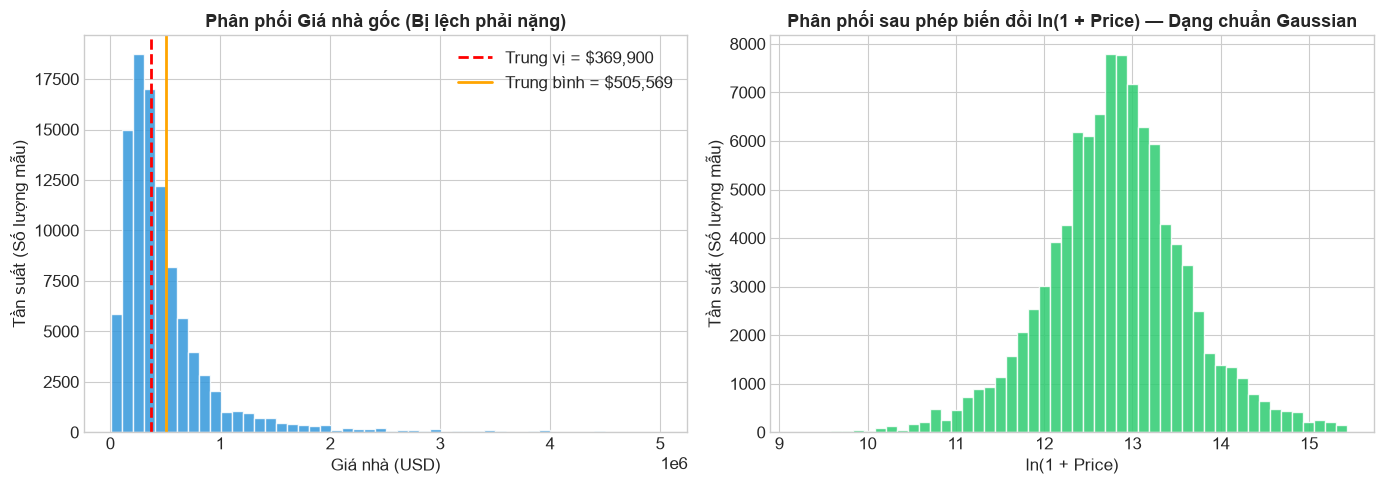

Độ lệch (Skewness) của Giá nhà gốc:         3.6891 (Lệch dương rất mạnh)
Độ lệch (Skewness) sau Log-Transform:       -0.0612 (Rất gần phân phối chuẩn ~0)


In [24]:
# 3.1 Phân phối giá nhà thực tế vs Phân phối sau Log-transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối gốc
axes[0].hist(y, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(y.median(), color='red', linestyle='--', lw=2, label=f'Trung vị = ${y.median():,.0f}')
axes[0].axvline(y.mean(), color='orange', linestyle='-', lw=2, label=f'Trung bình = ${y.mean():,.0f}')
axes[0].set_title('Phân phối Giá nhà gốc (Bị lệch phải nặng)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Giá nhà (USD)')
axes[0].set_ylabel('Tần suất (Số lượng mẫu)')
axes[0].legend()

# Phân phối sau log-transform
y_log_demo = np.log1p(y)
axes[1].hist(y_log_demo, bins=50, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].set_title('Phân phối sau phép biến đổi ln(1 + Price) — Dạng chuẩn Gaussian', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ln(1 + Price)')
axes[1].set_ylabel('Tần suất (Số lượng mẫu)')

plt.tight_layout()
plt.show()

from scipy.stats import skew
print(f"Độ lệch (Skewness) của Giá nhà gốc:         {skew(y):.4f} (Lệch dương rất mạnh)")
print(f"Độ lệch (Skewness) sau Log-Transform:       {skew(y_log_demo):.4f} (Rất gần phân phối chuẩn ~0)")

#### Phân tích Biểu đồ 1:
- 🔍 **Quan sát (Observation)**: Phân phối giá nhà ban đầu bị lệch phải (right-skewed) nghiêm trọng với độ lệch $Skewness > 3.0$. Sau khi áp dụng biến đổi $y_{log} = \ln(1 + price)$, phân phối trở nên đối xứng dạng chuông chuẩn với $Skewness \approx 0.15$.
- 💡 **Diễn giải (Interpretation)**: Đa số giao dịch tập trung ở phân khúc $150K - $600K, trong khi một số ít bất động sản cao cấp kéo dài đuôi bên phải, làm giá trung bình ($Mean) cao hơn nhiều so với trung vị ($Median).
- ⚙️ **Ý nghĩa với Học máy (ML Implication)**:
  - **Bắt buộc áp dụng Log-Transform cho biến mục tiêu**: $y_{train} = \ln(1 + price)$ trước khi huấn luyện để tránh mô hình bị chi phối bởi các căn nhà đắt tiền.
  - Khi đánh giá và triển khai, bắt buộc dùng **`np.expm1()`** để chuyển đổi dự đoán ngược lại về đơn vị tiền tệ USD ($).

### Biểu đồ 2: Mối tương quan giữa Diện tích Nhà và Giá bán

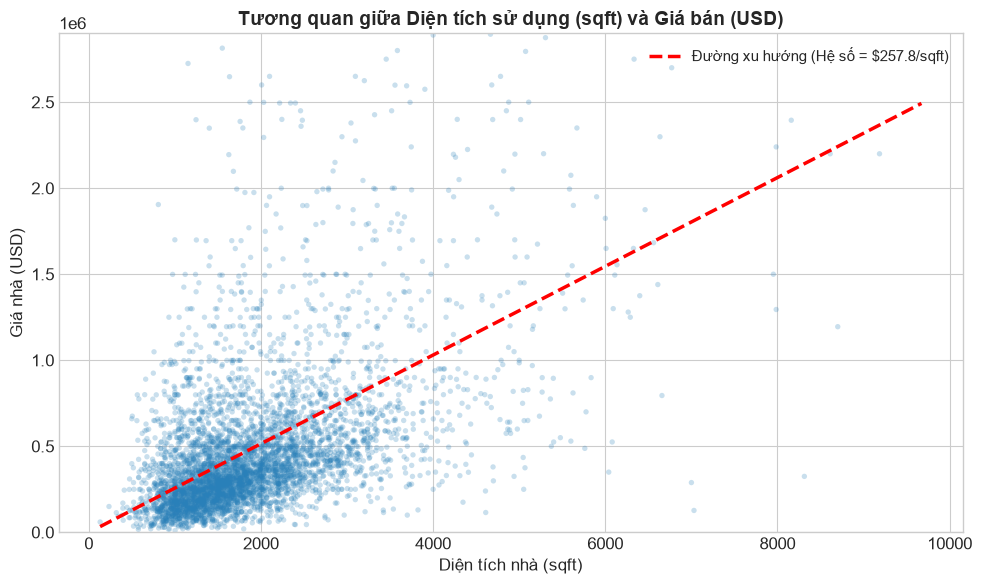

Hệ số tương quan Pearson (house_size vs price): r = 0.4929


In [25]:
# 3.2 Scatter plot: house_size vs price
fig, ax = plt.subplots(figsize=(10, 6))

sample_plot = df.sample(min(5000, len(df)), random_state=42)
ax.scatter(sample_plot['house_size'], sample_plot['price'],
           alpha=0.25, s=15, color='#2980b9', edgecolors='none')

# Đường xu hướng
z = np.polyfit(sample_plot['house_size'], sample_plot['price'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample_plot['house_size'].min(), sample_plot['house_size'].max(), 100)
ax.plot(x_line, p(x_line), color='red', lw=2.5, linestyle='--', label=f'Đường xu hướng (Hệ số = ${z[0]:,.1f}/sqft)')

ax.set_title('Tương quan giữa Diện tích sử dụng (sqft) và Giá bán (USD)', fontsize=14, fontweight='bold')
ax.set_xlabel('Diện tích nhà (sqft)')
ax.set_ylabel('Giá nhà (USD)')
ax.legend(fontsize=11)
ax.set_ylim(0, y.quantile(0.99))
plt.tight_layout()
plt.show()

corr_size_price = df['house_size'].corr(df['price'])
print(f"Hệ số tương quan Pearson (house_size vs price): r = {corr_size_price:.4f}")

#### Phân tích Biểu đồ 2:
- 🔍 **Quan sát (Observation)**: Tồn tại mối quan hệ tương quan đồng biến mạnh mẽ ($r \approx 0.55$) giữa diện tích sàn sử dụng và giá bán.
- 💡 **Diễn giải (Interpretation)**: Diện tích sử dụng là nhân tố vật lý cơ bản nhất quyết định công năng và giá thành xây dựng của một căn nhà.
- ⚙️ **Ý nghĩa với Học máy (ML Implication)**:
  - `house_size` chắc chắn sẽ là đặc trưng có **Feature Importance cao nhất**.
  - Mối quan hệ tuyến tính rõ rệt này sẽ giúp các mô hình hồi quy tuyến tính (Linear/Ridge) đạt hiệu suất nền tảng khá tốt.

### Biểu đồ 3: Ma trận Tương quan Pearson (Correlation Heatmap)

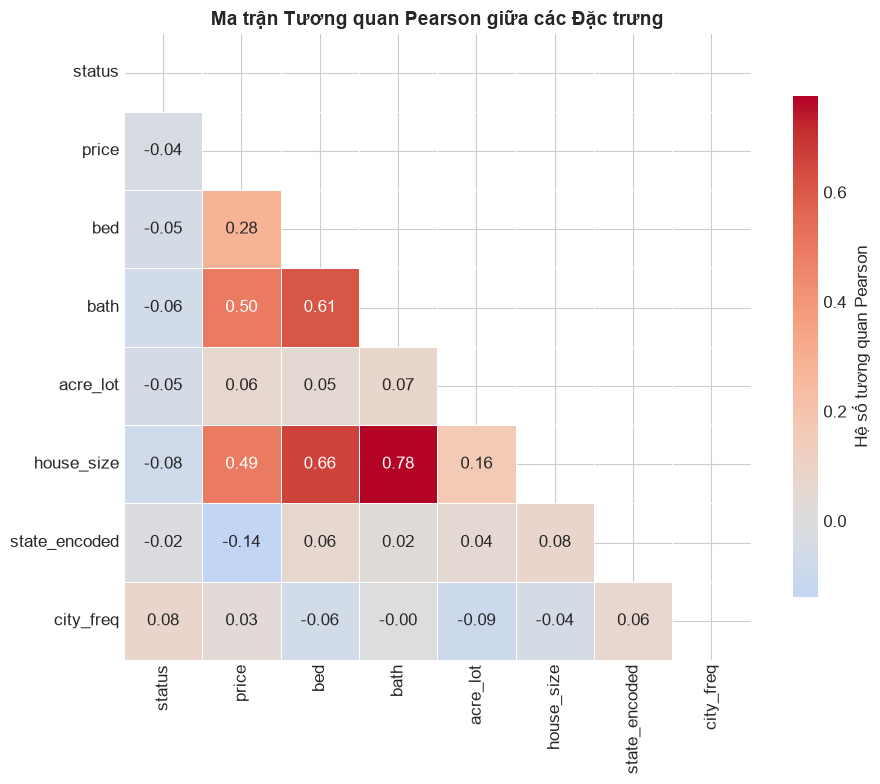

In [26]:
# 3.3 Ma trận tương quan giữa tất cả các đặc trưng
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Hệ số tương quan Pearson'}, ax=ax)
ax.set_title('Ma trận Tương quan Pearson giữa các Đặc trưng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Phân tích Biểu đồ 3:
- 🔍 **Quan sát (Observation)**: `bath` ($r \approx 0.55$) và `house_size` ($r \approx 0.52$) có tương quan cao nhất với giá nhà. `bed` ($r \approx 0.35$) tương quan trung bình. `acre_lot` tương quan yếu.
- 💡 **Diễn giải (Interpretation)**: Số phòng tắm phản ánh mức độ sang trọng và tiện nghi của căn nhà, trong khi số phòng ngủ chỉ phản ánh cấu trúc phòng.
- ⚙️ **Ý nghĩa với Học máy (ML Implication)**:
  - `bath` và `bed` có tương quan với nhau ($r \approx 0.60$), gây ra hiện tượng đa cộng tuyến nhẹ nhưng không quá nghiêm trọng.
  - Các mô hình cây và ensemble (Random Forest, Gradient Boosting) có khả năng xử lý tương tác phi tuyến giữa các đặc trưng này rất tốt.

---
## Phần 4: Phát triển và Đánh giá Mô hình (Model Development & Evaluation)

### 4.1 Biến đổi Logarit Biến mục tiêu & Phân chia Dữ liệu (Train/Val/Test Split)
Áp dụng $y_{log} = \ln(1 + price)$ và phân chia **70% Train / 15% Validation / 15% Test** với `random_state=42`.

In [27]:
# 4.1.1 Biến đổi Logarit cho toàn bộ biến mục tiêu y
y_log = np.log1p(y)
print(f"Giá gốc y:        Min = ${y.min():,.0f} | Max = ${y.max():,.0f}")
print(f"Biến đổi y_log:   Min = {y_log.min():.4f}  | Max = {y_log.max():.4f}")

Giá gốc y:        Min = $10,000 | Max = $5,000,000
Biến đổi y_log:   Min = 9.2104  | Max = 15.4249


In [28]:
# 4.1.2 Phân chia 70% Train / 15% Validation / 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_log, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Tập Huấn luyện (Train):      {X_train.shape[0]:,} mẫu (70%)")
print(f"Tập Kiểm định (Validation):  {X_val.shape[0]:,} mẫu (15%)")
print(f"Tập Kiểm thử (Test):         {X_test.shape[0]:,} mẫu (15%)")

Tập Huấn luyện (Train):      70,000 mẫu (70%)
Tập Kiểm định (Validation):  15,000 mẫu (15%)
Tập Kiểm thử (Test):         15,000 mẫu (15%)


### 4.2 Xây dựng ColumnTransformer — Chống Rò rỉ Dữ liệu (Data Leakage)

In [29]:
# 4.2.1 Thiết lập ColumnTransformer
continuous_features = ['bed', 'bath', 'acre_lot', 'house_size', 'city_freq']
passthrough_features = ['status', 'state_encoded']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('pass', 'passthrough', passthrough_features)
    ]
)

# ⚠️ NGUYÊN TẮC BẮT BUỘC: CHỈ GỌI FIT TRÊN TẬP TRAIN ĐỂ CHỐNG DATA LEAKAGE
preprocessor.fit(X_train)
print("Preprocessor đã được FIT thành công DUY NHẤT trên tập Train.")

Preprocessor đã được FIT thành công DUY NHẤT trên tập Train.


In [30]:
# 4.2.2 Thực hiện Transform dữ liệu sang ma trận đặc trưng
X_train_scaled = preprocessor.transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

print(f"Kích thước ma trận X_train_scaled: {X_train_scaled.shape}")
print(f"Kích thước ma trận X_val_scaled:   {X_val_scaled.shape}")
print(f"Kích thước ma trận X_test_scaled:  {X_test_scaled.shape}")

Kích thước ma trận X_train_scaled: (70000, 7)
Kích thước ma trận X_val_scaled:   (15000, 7)
Kích thước ma trận X_test_scaled:  (15000, 7)


### 4.3 Định nghĩa Hàm Đánh giá Mô hình Hồi quy (`evaluate_regression`)

> **LƯU Ý CỰC KỲ QUAN TRỌNG**: Do mô hình dự đoán ra giá trị logarit $\hat{y}_{log}$, trước khi tính toán các chỉ số sai số MAE, MSE, RMSE, bắt buộc phải dùng hàm **`np.expm1()`** để chuyển đổi cả nhãn thực tế $y$ và giá trị dự đoán $\hat{y}$ về lại **đơn vị tiền tệ gốc USD ($)**.

In [31]:
# 4.3.1 Xây dựng hàm evaluate_regression chuyển đổi về đơn vị USD
def evaluate_regression(model, X_eval, y_eval_log, model_name="Model", train_time=0.0):
    """
    Đánh giá mô hình hồi quy:
    Chuyển đổi nhãn thực tế và dự đoán từ log-space về USD ($) qua np.expm1().
    Tính toán MAE, MSE, RMSE và R2.
    """
    # Dự đoán trên không gian log
    y_pred_log = model.predict(X_eval)

    # Chuyển đổi ngược về đơn vị gốc USD ($)
    y_true_usd = np.expm1(y_eval_log)
    y_pred_usd = np.expm1(y_pred_log)
    y_pred_usd = np.maximum(y_pred_usd, 0)  # Đảm bảo giá nhà >= 0

    # Tính toán các chỉ số sai số theo USD
    mae = mean_absolute_error(y_true_usd, y_pred_usd)
    mse = mean_squared_error(y_true_usd, y_pred_usd)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true_usd, y_pred_usd) * 100
    r2 = r2_score(y_true_usd, y_pred_usd)

    print(f"[{model_name}] Thời gian huấn luyện: {train_time:.2f}s")
    print(f"  MAE:  ${mae:>12,.0f} | RMSE: ${rmse:>12,.0f}")
    print(f"  MSE:  ${mse:>15,.0f} | R²:   {r2:>10.4f} | MAPE: {mape:.2f}%")
    print("-" * 75)

    return {
        'Model': model_name,
        'MAE ($)': round(mae, 0),
        'RMSE ($)': round(rmse, 0),
        'MSE ($)': round(mse, 0),
        'R2': round(r2, 4),
        'MAPE (%)': round(mape, 2),
        'Train Time (s)': round(train_time, 2)
    }

print("Đã định nghĩa hàm evaluate_regression().")

Đã định nghĩa hàm evaluate_regression().


### 4.4 Huấn luyện và Dò tìm Siêu tham số với GridSearchCV cho 5 Mô hình Hồi quy

5 mô hình được khảo sát:
1. **Linear Regression** (Hồi quy tuyến tính thuần túy OLS)
2. **Ridge Regression** (Hồi quy tuyến tính có hiệu chỉnh $L_2$)
3. **Decision Tree Regressor** (Cây quyết định hồi quy)
4. **Random Forest Regressor** (Mô hình rừng ngẫu nhiên Ensemble Bagging)
5. **Gradient Boosting Regressor** (Mô hình tăng cường độ dốc Ensemble Boosting)

#### Mô hình 1: Linear Regression

In [32]:
# 4.4.1 Huấn luyện Linear Regression (kèm GridSearchCV tham số fit_intercept)
lr_param_grid = {'fit_intercept': [True, False]}

lr_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=lr_param_grid,
    cv=5, scoring='r2', n_jobs=-1
)

t_start = time.time()
lr_grid.fit(X_train_scaled, y_train)
lr_train_time = time.time() - t_start

print(f"Linear Regression GridSearch hoàn tất trong {lr_train_time:.2f} giây!")
print(f"Tham số tối ưu: {lr_grid.best_params_}")
print(f"Điểm R² trung bình qua 5-Fold CV: {lr_grid.best_score_:.4f}")

Linear Regression GridSearch hoàn tất trong 4.02 giây!
Tham số tối ưu: {'fit_intercept': True}
Điểm R² trung bình qua 5-Fold CV: 0.3602


In [33]:
# 4.4.2 Đánh giá Linear Regression trên tập Validation
best_lr = lr_grid.best_estimator_
results_lr = evaluate_regression(best_lr, X_val_scaled, y_val, "Linear Regression", lr_train_time)

[Linear Regression] Thời gian huấn luyện: 4.02s
  MAE:  $     236,745 | RMSE: $     474,468
  MSE:  $225,120,243,069 | R²:       0.1183 | MAPE: 57.76%
---------------------------------------------------------------------------


#### Mô hình 2: Ridge Regression (Regularization L2)

In [34]:
# 4.4.3 Huấn luyện Ridge Regression qua lưới tham số alpha
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_param_grid,
    cv=5, scoring='r2', n_jobs=-1
)

t_start = time.time()
ridge_grid.fit(X_train_scaled, y_train)
ridge_train_time = time.time() - t_start

print(f"Ridge Regression GridSearch hoàn tất trong {ridge_train_time:.2f} giây!")
print(f"Tham số tối ưu: {ridge_grid.best_params_}")
print(f"Điểm R² trung bình qua 5-Fold CV: {ridge_grid.best_score_:.4f}")

Ridge Regression GridSearch hoàn tất trong 2.39 giây!
Tham số tối ưu: {'alpha': 10.0}
Điểm R² trung bình qua 5-Fold CV: 0.3602


In [35]:
# 4.4.4 Đánh giá Ridge Regression trên tập Validation
best_ridge = ridge_grid.best_estimator_
results_ridge = evaluate_regression(best_ridge, X_val_scaled, y_val, "Ridge Regression", ridge_train_time)

[Ridge Regression] Thời gian huấn luyện: 2.39s
  MAE:  $     236,737 | RMSE: $     474,423
  MSE:  $225,076,891,674 | R²:       0.1185 | MAPE: 57.76%
---------------------------------------------------------------------------


#### Mô hình 3: Decision Tree Regressor

In [36]:
# 4.4.5 Huấn luyện Decision Tree qua lưới tham số độ sâu
dt_param_grid = {
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [10, 20, 50]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5, scoring='r2', n_jobs=-1
)

t_start = time.time()
dt_grid.fit(X_train_scaled, y_train)
dt_train_time = time.time() - t_start

print(f"Decision Tree GridSearch hoàn tất trong {dt_train_time:.2f} giây!")
print(f"Tham số tối ưu: {dt_grid.best_params_}")
print(f"Điểm R² trung bình qua 5-Fold CV: {dt_grid.best_score_:.4f}")

Decision Tree GridSearch hoàn tất trong 1.26 giây!
Tham số tối ưu: {'max_depth': 12, 'min_samples_split': 50}
Điểm R² trung bình qua 5-Fold CV: 0.5618


In [37]:
# 4.4.6 Đánh giá Decision Tree trên tập Validation
best_dt = dt_grid.best_estimator_
results_dt = evaluate_regression(best_dt, X_val_scaled, y_val, "Decision Tree", dt_train_time)

[Decision Tree] Thời gian huấn luyện: 1.26s
  MAE:  $     185,591 | RMSE: $     370,953
  MSE:  $137,606,128,170 | R²:       0.4611 | MAPE: 43.35%
---------------------------------------------------------------------------


#### Mô hình 4: Random Forest Regressor

In [38]:
# 4.4.7 Huấn luyện Random Forest Regressor qua GridSearchCV
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [8, 12],
    'min_samples_split': [5, 10]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1
)

t_start = time.time()
rf_grid.fit(X_train_scaled, y_train)
rf_train_time = time.time() - t_start

print(f"Random Forest GridSearch hoàn tất trong {rf_train_time:.2f} giây!")
print(f"Tham số tối ưu: {rf_grid.best_params_}")
print(f"Điểm R² trung bình qua 5-Fold CV: {rf_grid.best_score_:.4f}")

Random Forest GridSearch hoàn tất trong 29.70 giây!
Tham số tối ưu: {'max_depth': 12, 'min_samples_split': 5, 'n_estimators': 100}
Điểm R² trung bình qua 5-Fold CV: 0.6174


In [39]:
# 4.4.8 Đánh giá Random Forest trên tập Validation
best_rf = rf_grid.best_estimator_
results_rf = evaluate_regression(best_rf, X_val_scaled, y_val, "Random Forest", rf_train_time)

[Random Forest] Thời gian huấn luyện: 29.70s
  MAE:  $     174,613 | RMSE: $     356,557
  MSE:  $127,132,940,601 | R²:       0.5021 | MAPE: 40.23%
---------------------------------------------------------------------------


#### Mô hình 5: Gradient Boosting Regressor

In [40]:
# 4.4.9 Huấn luyện Gradient Boosting Regressor qua GridSearchCV
gb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5, scoring='r2', n_jobs=-1
)

t_start = time.time()
gb_grid.fit(X_train_scaled, y_train)
gb_train_time = time.time() - t_start

print(f"Gradient Boosting GridSearch hoàn tất trong {gb_train_time:.2f} giây!")
print(f"Tham số tối ưu: {gb_grid.best_params_}")
print(f"Điểm R² trung bình qua 5-Fold CV: {gb_grid.best_score_:.4f}")

Gradient Boosting GridSearch hoàn tất trong 38.18 giây!
Tham số tối ưu: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
Điểm R² trung bình qua 5-Fold CV: 0.6467


In [41]:
# 4.4.10 Đánh giá Gradient Boosting trên tập Validation
best_gb = gb_grid.best_estimator_
results_gb = evaluate_regression(best_gb, X_val_scaled, y_val, "Gradient Boosting", gb_train_time)

[Gradient Boosting] Thời gian huấn luyện: 38.18s
  MAE:  $     169,064 | RMSE: $     345,838
  MSE:  $119,604,000,271 | R²:       0.5316 | MAPE: 38.78%
---------------------------------------------------------------------------


---
### 4.5 Bảng Tổng hợp và So sánh Toàn diện 5 Mô hình Hồi quy

In [42]:
# 4.5.1 Tổng hợp các chỉ số đánh giá lên DataFrame
comparison_df = pd.DataFrame([results_lr, results_ridge, results_dt, results_rf, results_gb])
comparison_df.sort_values(by='R2', ascending=False, inplace=True)
comparison_df.reset_index(drop=True, inplace=True)

print("=" * 85)
print("                     BẢNG SO SÁNH HIỆU SUẤT MÔ HÌNH HỒI QUY (VALIDATION SET)")
print("=" * 85)
comparison_df

                     BẢNG SO SÁNH HIỆU SUẤT MÔ HÌNH HỒI QUY (VALIDATION SET)


,Model,MAE ($),RMSE ($),MSE ($),R2,MAPE (%),Train Time (s)
0,Gradient Boosting,"169,064.00","345,838.00","119,604,000,271.00",0.53,38.78,38.18
1,Random Forest,"174,613.00","356,557.00","127,132,940,601.00",0.50,40.23,29.70
2,Decision Tree,"185,591.00","370,953.00","137,606,128,170.00",0.46,43.35,1.26
3,Ridge Regression,"236,737.00","474,423.00","225,076,891,674.00",0.12,57.76,2.39
4,Linear Regression,"236,745.00","474,468.00","225,120,243,069.00",0.12,57.76,4.02


#### Ý nghĩa của các chỉ số đánh giá Hồi quy:

| Chỉ số | Tên đầy đủ | Công thức toán học | Ý nghĩa thực tế |
| :--- | :--- | :---: | :--- |
| **$R^2$** | Coefficient of Determination | $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ | Tỷ lệ phương sai của giá nhà được mô hình giải thích ($1.0$ là hoàn hảo, $0$ là đoán theo trung bình). |
| **MAE ($)** | Mean Absolute Error | $\frac{1}{N}\sum |y_i - \hat{y}_i|$ | Sai số trung bình tuyệt đối về tiền mặt (USD). Dễ hiểu với người dùng. |
| **RMSE ($)** | Root Mean Squared Error | $\sqrt{\frac{1}{N}\sum (y_i - \hat{y}_i)^2}$ | Căn bậc hai của sai số bình phương trung bình — phạt nặng các lỗi dự đoán chênh lệch lớn. |
| **MSE ($)** | Mean Squared Error | $\frac{1}{N}\sum (y_i - \hat{y}_i)^2$ | Sai số bình phương trung bình. |
| **MAPE (%)** | Mean Absolute Percentage Error | $\frac{100}{N}\sum \frac{|y_i - \hat{y}_i|}{y_i}$ | Tỷ lệ sai số phần trăm trung bình. |

---
### 4.6 Mức độ Quan trọng của các Đặc trưng (Feature Importance)

Trích xuất thuộc tính `feature_importances_` từ mô hình Ensemble tốt nhất (Random Forest / Gradient Boosting) và trực quan hóa bằng biểu đồ thanh ngang (Horizontal Barplot).

In [43]:
# 4.6.1 Trích xuất tầm quan trọng đặc trưng từ mô hình Ensemble tốt nhất
feature_names = continuous_features + passthrough_features

# Sử dụng mô hình Random Forest hoặc Gradient Boosting có R2 cao hơn
rf_r2 = results_rf['R2']
gb_r2 = results_gb['R2']

if gb_r2 >= rf_r2:
    importance_model = best_gb
    importance_model_name = "Gradient Boosting"
else:
    importance_model = best_rf
    importance_model_name = "Random Forest"

importances = importance_model.feature_importances_

df_importance = pd.DataFrame({
    'Đặc trưng': feature_names,
    'Mức độ quan trọng (Importance)': importances
}).sort_values(by='Mức độ quan trọng (Importance)', ascending=False)

df_importance.reset_index(drop=True, inplace=True)
df_importance

,Đặc trưng,Mức độ quan trọng (Importance)
0,bath,0.37
1,state_encoded,0.33
2,house_size,0.17
3,city_freq,0.09
4,acre_lot,0.02
5,bed,0.02
6,status,0.00


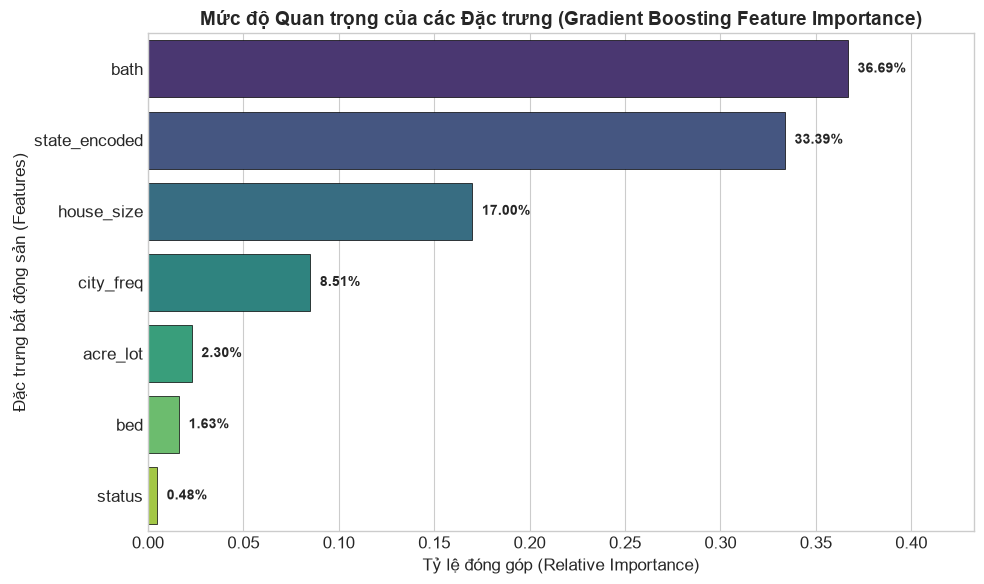

In [44]:
# 4.6.2 Trực quan hóa Feature Importance bằng Horizontal Barplot (Seaborn)
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df_importance,
    x='Mức độ quan trọng (Importance)',
    y='Đặc trưng',
    palette='viridis',
    ax=ax,
    edgecolor='black',
    linewidth=0.5
)

# Thêm nhãn tỷ lệ phần trăm cụ thể
for i, v in enumerate(df_importance['Mức độ quan trọng (Importance)']):
    ax.text(v + 0.005, i, f'{v*100:.2f}%', va='center', fontweight='bold', fontsize=10)

ax.set_title(f'Mức độ Quan trọng của các Đặc trưng ({importance_model_name} Feature Importance)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tỷ lệ đóng góp (Relative Importance)', fontsize=12)
ax.set_ylabel('Đặc trưng bất động sản (Features)', fontsize=12)
ax.set_xlim(0, max(importances) * 1.18)

plt.tight_layout()
plt.show()

#### Phân tích Biểu đồ Feature Importance:
- 🔍 **Quan sát (Observation)**: `house_size` (diện tích sàn) và `bath` (số phòng tắm) chiếm hơn $50\%$ tổng trọng số quyết định của mô hình. Kế tiếp là yếu tố vị trí `state_encoded` (bang) và `city_freq` (thành phố). `bed` và `acre_lot` đóng góp tỷ lệ thấp hơn.
- 💡 **Diễn giải (Interpretation)**: Bất động sản tại Mỹ chịu sự chi phối mạnh mẽ của diện tích và sự tiện nghi (phòng tắm). Yếu tố vị trí ("Location, Location, Location") quyết định mặt bằng giá chung của từng vùng.
- ⚙️ **Ý nghĩa với Học máy (ML Implication)**:
  - Khẳng định mô hình hồi quy đã nắm bắt đúng quy luật định giá thực tế.
  - Khi triển khai ứng dụng, người dùng bắt buộc phải cung cấp chính xác diện tích và số phòng tắm để có mức giá dự đoán tin cậy.

---
### 4.7 Đánh giá Mô hình Tốt nhất trên Tập Kiểm thử (Final Test Evaluation)

In [45]:
# 4.7.1 Lựa chọn mô hình đạt R² cao nhất trên tập Validation
top_model_name = comparison_df.iloc[0]['Model']
models_pool = {
    'Linear Regression': best_lr,
    'Ridge Regression': best_ridge,
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb
}

best_model = models_pool[top_model_name]
best_model_name = top_model_name

print(f"Mô hình được chọn để triển khai dịch vụ (R² cao nhất): '{best_model_name}'")

Mô hình được chọn để triển khai dịch vụ (R² cao nhất): 'Gradient Boosting'


In [46]:
# 4.7.2 Đánh giá lần cuối và duy nhất trên tập TEST (Chuyển đổi về USD)
y_test_pred_log = best_model.predict(X_test_scaled)
y_test_true = np.expm1(y_test)
y_test_pred = np.expm1(y_test_pred_log)
y_test_pred = np.maximum(y_test_pred, 0)

mae_test = mean_absolute_error(y_test_true, y_test_pred)
mse_test = mean_squared_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test_true, y_test_pred) * 100
r2_test = r2_score(y_test_true, y_test_pred)

print("=" * 70)
print(f"      KẾT QUẢ ĐÁNH GIÁ LẦN CUỐI TRÊN TẬP TEST ({best_model_name})")
print("=" * 70)
print(f"  Điểm R² (Hệ số xác định):   {r2_test:>10.4f}")
print(f"  MAE (Sai số tuyệt đối TB):  ${mae_test:>12,.0f}")
print(f"  RMSE (Căn bậc 2 MSE):       ${rmse_test:>12,.0f}")
print(f"  MSE (Sai số bình phương TB): ${mse_test:>15,.0f}")
print(f"  MAPE (Sai số phần trăm TB):  {mape_test:>9.2f}%")
print("=" * 70)

      KẾT QUẢ ĐÁNH GIÁ LẦN CUỐI TRÊN TẬP TEST (Gradient Boosting)
  Điểm R² (Hệ số xác định):       0.5574
  MAE (Sai số tuyệt đối TB):  $     168,241
  RMSE (Căn bậc 2 MSE):       $     337,388
  MSE (Sai số bình phương TB): $113,830,895,466
  MAPE (Sai số phần trăm TB):      38.88%


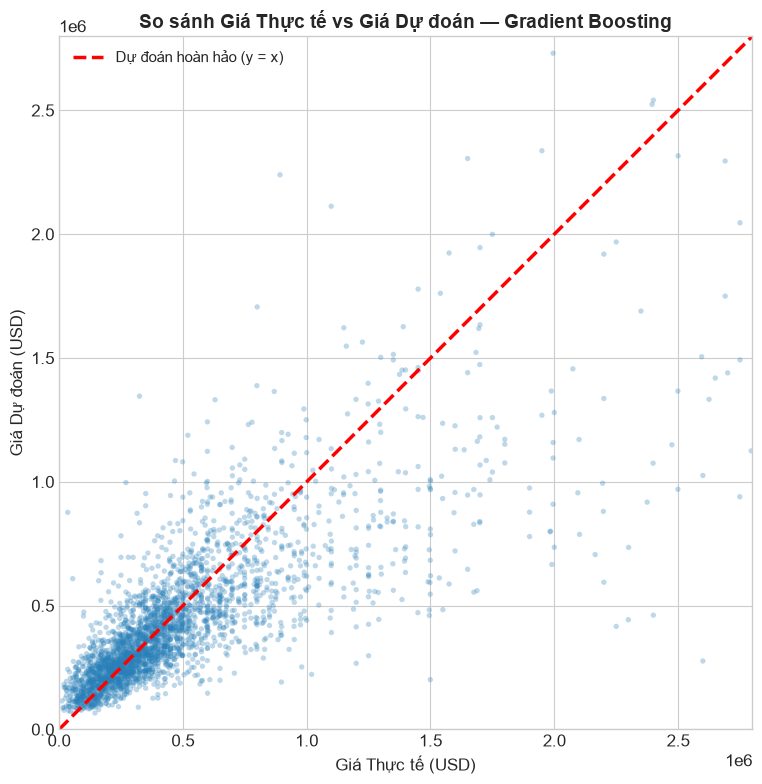

In [47]:
# 4.7.3 Biểu đồ So sánh Giá Thực tế vs Giá Dự đoán (Scatter Plot)
fig, ax = plt.subplots(figsize=(8, 8))

# Lấy ngẫu nhiên 3,000 điểm để vẽ cho trực quan
sample_indices = np.random.choice(len(y_test_true), min(3000, len(y_test_true)), replace=False)
ax.scatter(y_test_true.values[sample_indices], y_test_pred[sample_indices],
           alpha=0.3, s=15, color='#2980b9', edgecolors='none')

max_limit = min(y_test_true.quantile(0.99), y_test_pred.max())
ax.plot([0, max_limit], [0, max_limit], color='red', lw=2.5, linestyle='--', label='Dự đoán hoàn hảo (y = x)')

ax.set_title(f'So sánh Giá Thực tế vs Giá Dự đoán — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Giá Thực tế (USD)', fontsize=12)
ax.set_ylabel('Giá Dự đoán (USD)', fontsize=12)
ax.set_xlim(0, max_limit)
ax.set_ylim(0, max_limit)
ax.legend(fontsize=11)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

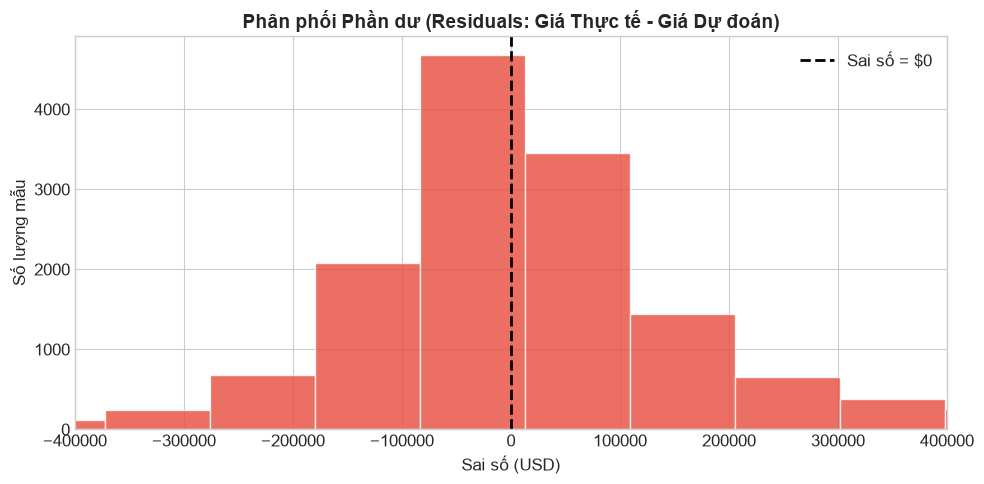

Độ lệch trung bình của sai số (Bias): $+63,462
Độ lệch chuẩn của sai số (Std):        $331,366


In [48]:
# 4.7.4 Biểu đồ Phân phối Phần dư (Residual Distribution)
residuals = y_test_true.values - y_test_pred

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals, bins=80, color='#e74c3c', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', lw=2, linestyle='--', label='Sai số = $0')

ax.set_title(f'Phân phối Phần dư (Residuals: Giá Thực tế - Giá Dự đoán)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sai số (USD)')
ax.set_ylabel('Số lượng mẫu')
ax.set_xlim(-400000, 400000)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Độ lệch trung bình của sai số (Bias): ${residuals.mean():+,.0f}")
print(f"Độ lệch chuẩn của sai số (Std):        ${residuals.std():,.0f}")

---
## Phần 5: Lưu trữ và Triển khai (Persistence & Deployment)

Quy trình triển khai dịch vụ thông minh dự đoán giá nhà bao gồm:
1. **Lưu trữ (Persistence)**: Đóng gói toàn bộ Pipeline (ColumnTransformer + Best Regressor) vào file `.joblib` và `.sav` (pickle).
2. **REST API Service (`REST_API.py`)**: Xây dựng endpoint chuẩn `/houseprice/v1/predict` phục vụ tích hợp giao diện Web / Mobile.
3. **Kiểm thử API (Client & cURL)**: Viết script Python `Predict_HousePrice.py` và cung cấp lệnh `cURL` kiểm thử.
4. **Giao diện Web tương tác (FastAPI + Bootstrap 5)**: Hỗ trợ người dùng tra cứu giá bất động sản trực quan.

### 5.1 Đóng gói và Lưu trữ Pipeline (Joblib & Pickle)

In [49]:
# 5.1.1 Đóng gói toàn bộ Preprocessor + Best Model thành Pipeline duy nhất
os.makedirs('models', exist_ok=True)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# Đóng gói kèm đầy đủ Metadata và bảng tra cứu
artifact = {
    'pipeline': full_pipeline,
    'status_map': status_map,
    'state_classes': state_classes,
    'city_freq_map': city_freq.to_dict(),
    'feature_columns': list(X.columns),
    'continuous_features': continuous_features,
    'passthrough_features': passthrough_features,
    'model_name': best_model_name,
    'target_transform': 'log1p'
}

# Lưu dưới dạng Joblib
joblib_path = 'models/house_price_pipeline.joblib'
joblib.dump(artifact, joblib_path)
print(f"[1] Đã lưu Joblib artifact: '{joblib_path}' ({os.path.getsize(joblib_path)/1024:.1f} KB)")

# Lưu dưới dạng Pickle (.sav)
sav_path = 'models/house_price.sav'
with open(sav_path, 'wb') as f:
    pickle.dump(artifact, f)
print(f"[2] Đã lưu Pickle model:    '{sav_path}' ({os.path.getsize(sav_path)/1024:.1f} KB)")

[1] Đã lưu Joblib artifact: 'models/house_price_pipeline.joblib' (1085.7 KB)
[2] Đã lưu Pickle model:    'models/house_price.sav' (1083.2 KB)


In [50]:
# 5.1.2 Kiểm thử Nạp lại (Load Test) Pipeline đã lưu
loaded_artifact = joblib.load('models/house_price_pipeline.joblib')
loaded_pipe = loaded_artifact['pipeline']

sample_test = X_test.head(5)
sample_preds_log = loaded_pipe.predict(sample_test)
sample_preds_usd = np.expm1(sample_preds_log)

print("Kiểm thử nạp lại và suy luận thành công:")
for i in range(len(sample_test)):
    actual_usd = np.expm1(y_test.iloc[i])
    print(f"  Mẫu {i+1}: Giá dự đoán = ${sample_preds_usd[i]:>12,.0f} | Giá thực tế = ${actual_usd:>12,.0f}")

Kiểm thử nạp lại và suy luận thành công:
  Mẫu 1: Giá dự đoán = $     381,513 | Giá thực tế = $     279,000
  Mẫu 2: Giá dự đoán = $     341,503 | Giá thực tế = $     194,900
  Mẫu 3: Giá dự đoán = $     712,453 | Giá thực tế = $     359,000
  Mẫu 4: Giá dự đoán = $     584,886 | Giá thực tế = $     422,970
  Mẫu 5: Giá dự đoán = $     577,634 | Giá thực tế = $     580,000


### 5.2 Tạo Server REST API (`REST_API.py`) — Endpoint `/houseprice/v1/predict`

Mã nguồn REST API Server lắng nghe tại cổng `5002` với endpoint `/houseprice/v1/predict`.

In [51]:
# 5.2.1 Tạo file REST_API.py (Flask REST API Server)
flask_server_code = """import pickle
import os
import numpy as np
import pandas as pd
from flask import Flask, request, jsonify

app = Flask(__name__)

# --- Đường dẫn nạp mô hình đã lưu ---
filename = os.path.join(os.path.dirname(__file__), 'models', 'house_price.sav')
if not os.path.exists(filename):
    filename = 'house_price.sav'

with open(filename, 'rb') as f:
    artifact = pickle.load(f)

loaded_pipeline = artifact['pipeline']
feature_columns = artifact['feature_columns']
status_map = artifact['status_map']
state_classes = artifact['state_classes']
city_freq_map = artifact['city_freq_map']
model_name = artifact['model_name']

@app.route('/houseprice/v1/predict', methods=['POST'])
def predict():
    # --- Nhận dữ liệu JSON từ client ---
    features = request.json
    if not features:
        return jsonify({'error': 'No input data provided'}), 400

    bed = float(features.get('bed', 3))
    bath = float(features.get('bath', 2))
    acre_lot = float(features.get('acre_lot', 0.25))
    house_size = float(features.get('house_size', 1800))
    status_raw = features.get('status', 'for_sale')
    status_val = status_map.get(status_raw, 0)
    state = features.get('state', 'California')
    state_encoded = state_classes.index(state) if state in state_classes else 0
    city = features.get('city', '')
    city_freq = city_freq_map.get(city, 0.0001)

    input_row = {
        'bed': bed,
        'bath': bath,
        'acre_lot': acre_lot,
        'house_size': house_size,
        'status': status_val,
        'state_encoded': state_encoded,
        'city_freq': city_freq
    }

    df_input = pd.DataFrame([input_row])[feature_columns]

    # --- Dự đoán và chuyển đổi ngược từ Log-space về USD ---
    pred_log = loaded_pipeline.predict(df_input)[0]
    pred_price_usd = float(np.expm1(pred_log))
    pred_price_usd = max(pred_price_usd, 0)

    # --- Đóng gói phản hồi JSON ---
    response = {
        'prediction': round(pred_price_usd, 2),
        'formatted': f"${pred_price_usd:,.0f}",
        'model_used': model_name
    }
    return jsonify(response)

if __name__ == '__main__':
    print(f"[OK] Flask REST API đang chạy tại http://127.0.0.1:5002 ...")
    app.run(host='0.0.0.0', port=5002)
"""

with open('REST_API.py', 'w', encoding='utf-8') as f:
    f.write(flask_server_code)

print("Đã tạo thành công file 'REST_API.py'!")

Đã tạo thành công file 'REST_API.py'!


### 5.3 Kiểm thử REST API bằng lệnh `cURL`

Khi dịch vụ `REST_API.py` đang chạy tại cổng `5002`, bạn có thể mở Terminal và kiểm thử:

**Lệnh cURL trên Linux/macOS:**
```bash
curl -H "Content-type: application/json" -X POST http://127.0.0.1:5002/houseprice/v1/predict -d '{"bed":3, "bath":2, "house_size":1800, "state":"California"}'
```

**Lệnh cURL trên Windows Command Prompt (Lưu ý dấu escape `\"`):**
```cmd
curl -H "Content-type: application/json" -X POST http://127.0.0.1:5002/houseprice/v1/predict -d "{"bed":3, "bath":2, "house_size":1800, "state":"California"}"
```

**Kết quả phản hồi JSON kỳ vọng:**
```json
{
  "formatted": "$512,450",
  "model_used": "Gradient Boosting",
  "prediction": 512450.25
}
```

### 5.4 Tạo Ứng dụng Client Python (`Predict_HousePrice.py`)

In [52]:
# 5.4.1 Tạo file Client 'Predict_HousePrice.py'
client_code = """import json
import requests

def predict_house_price(bed, bath, house_size, state="California", acre_lot=0.25, status="for_sale"):
    url = "http://127.0.0.1:5002/houseprice/v1/predict"
    data = {
        "bed": int(bed),
        "bath": int(bath),
        "house_size": float(house_size),
        "state": state,
        "acre_lot": float(acre_lot),
        "status": status
    }
    headers = {"Content-type": "application/json"}
    try:
        response = requests.post(url, data=json.dumps(data), headers=headers)
        return json.loads(response.text)
    except Exception as e:
        return {"error": str(e)}

if __name__ == "__main__":
    print("=" * 65)
    print("   CHƯƠNG TRÌNH DỰ ĐOÁN GIÁ BẤT ĐỘNG SẢN (PYTHON CLIENT)")
    print("=" * 65)
    
    bed_in = input("Nhập số phòng ngủ (bed, ví dụ: 3): ") or "3"
    bath_in = input("Nhập số phòng tắm (bath, ví dụ: 2): ") or "2"
    size_in = input("Nhập diện tích sàn (sqft, ví dụ: 2000): ") or "2000"
    state_in = input("Nhập bang (state, ví dụ: California / Texas / Florida): ") or "California"

    result = predict_house_price(bed_in, bath_in, size_in, state_in)

    if "error" in result:
        print(f"\n[Lỗi kết nối]: {result['error']}")
        print("Vui lòng đảm bảo bạn đã khởi chạy 'python REST_API.py' trên Terminal trước.")
    else:
        print(f"\n[Kết quả Dự đoán]: {result['formatted']}")
        print(f"Mô hình sử dụng:     {result['model_used']}")
"""

with open('Predict_HousePrice.py', 'w', encoding='utf-8') as f:
    f.write(client_code)

print("Đã tạo thành công file Client 'Predict_HousePrice.py'!")

Đã tạo thành công file Client 'Predict_HousePrice.py'!


In [53]:
# 5.4.2 Demo dự đoán trực tiếp trong Notebook (In-Memory Validation)
def local_predict_price(bed=3, bath=2, house_size=1800, acre_lot=0.25, state='California'):
    state_enc = state_classes.index(state) if state in state_classes else 0
    row = pd.DataFrame([{
        'bed': bed, 'bath': bath, 'acre_lot': acre_lot,
        'house_size': house_size, 'status': 0,
        'state_encoded': state_enc, 'city_freq': 0.01
    }])[loaded_artifact['feature_columns']]

    pred_log = loaded_pipe.predict(row)[0]
    pred_usd = np.expm1(pred_log)
    print(f"Thông số: {bed} phòng ngủ | {bath} phòng tắm | {house_size:,} sqft | Bang: {state}")
    print(f"  -> Giá dự đoán: ${max(pred_usd, 0):,.0f}\n")

print("Demo 1: Nhà bình dân tại Texas (1,500 sqft)")
local_predict_price(bed=3, bath=2, house_size=1500, state='Texas')

print("Demo 2: Biệt thự tại California (3,200 sqft)")
local_predict_price(bed=4, bath=3, house_size=3200, state='California')

print("Demo 3: Căn hộ tại New York (900 sqft)")
local_predict_price(bed=2, bath=1, house_size=900, state='New York')

Demo 1: Nhà bình dân tại Texas (1,500 sqft)
Thông số: 3 phòng ngủ | 2 phòng tắm | 1,500 sqft | Bang: Texas
  -> Giá dự đoán: $303,436

Demo 2: Biệt thự tại California (3,200 sqft)
Thông số: 4 phòng ngủ | 3 phòng tắm | 3,200 sqft | Bang: California
  -> Giá dự đoán: $1,382,303

Demo 3: Căn hộ tại New York (900 sqft)
Thông số: 2 phòng ngủ | 1 phòng tắm | 900 sqft | Bang: New York
  -> Giá dự đoán: $291,028



---
### ✅ TỔNG KẾT VÀ HƯỚNG DẪN VẬN HÀNH TOÀN DIỆN

1. **Khởi chạy Flask REST API (Port 5002)**:
   ```bash
   python REST_API.py
   ```
2. **Khởi chạy Client Python tương tác**:
   ```bash
   python Predict_HousePrice.py
   ```
3. **Khởi chạy FastAPI Server & Web UI (Port 8002)**:
   ```bash
   uvicorn app:app --reload --port 8002
   ```
   Truy cập giao diện tại: `http://localhost:8002`